# 01 - Exploratory Data Analysis

**Phase 1 (Weeks 1-2)** of the Portuguese wildfire catastrophe loss model.

This notebook loads a real per-fire wildfire database for Portugal and
explores the resulting frequency and severity patterns.

See `docs/phase1-plan.md` and `docs/worklog.md` in the repo root for the
full data-sourcing story. In short:

- The primary data source is EFFIS's own Rapid Damage Assessment (MODIS-
  based) fire database, obtained via EFFIS's official Data Request Form
  (a one-time manual submission, since EFFIS's live Statistics Portal has
  no public JSON API). This gives real per-fire dates, real NUTS2 region
  locations, and real burned areas for Portugal, 2010-2024.
- This product maps fires of roughly 30 ha or larger (per EFFIS's own
  documentation), representing an estimated 75-80% of total burnt area
  despite being a minority of total fire count. **A "fire event" in this
  model therefore means a mapped ~30ha+ fire, not every ignition** - a
  deliberate scope choice consistent with how catastrophe models focus on
  material events, not a hidden gap.
- No public source publishes verified EUR loss per individual fire. A
  documented EUR/ha calibration constant (derived from published ICNF/OECD
  aggregate figures) is applied to real burned areas instead.
- Live OWID/GWIS annual aggregates are still fetched, but only as an
  independent cross-check against the real per-fire data, not as a
  modeling input. See "Data gaps and assumptions" below for what that
  cross-check found.

## Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import requests

from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY = "Portugal"
MAX_YEAR = 2024  # freeze scope to the PRD window; excludes the still-in-progress current season

## Data loading

`load_effis_fire_database` reads the real, committed per-fire snapshot
(the primary data source). `fetch_annual_fire_counts` and
`fetch_annual_burnt_area` pull live OWID/GWIS aggregates used only for
cross-validation further down, not as modeling inputs.

In [2]:
def load_effis_fire_database(path: Path = RAW_DIR / "effis_fire_database_pt_2010_2024.csv") -> pd.DataFrame:
    """Load the real per-fire EFFIS Rapid Damage Assessment database for Portugal.

    Source: EFFIS's official Data Request Form (forest-fire.emergency.
    copernicus.eu/apps/data.request.form/), dataset "Burnt area mapped
    using Sentinel2/MODIS images", Portugal, 2010-01-01 to 2024-12-31.
    Obtained as a one-time manual submission (not a live API), so this
    file is a static, committed snapshot rather than something re-fetched
    on each run - no reproducibility drift risk for this component.

    Per EFFIS's own documentation (see the accompanying .readme.txt in
    data/raw/), this product maps fires of roughly 30 ha or larger, which
    still represents an estimated 75-80% of Portugal's total burnt area
    despite being a minority of total fire count. Two cleaning steps are
    applied: ~40 of 6,608 raw records with area_ha <= 0 are dropped as
    non-physical mapping artifacts (EFFIS's own caveats about small/
    unmapped islands within a burn scar), and 69 exact duplicate records
    (same parish, area, and timestamp logged under a different id, ~104 ha
    total, concentrated in 2021-2024) are deduplicated as a confirmed
    export artifact - see docs/worklog.md for how this was found.

    Parameters
    ----------
    path : Path
        Location of the committed raw EFFIS export.

    Returns
    -------
    pd.DataFrame
        Columns: Date, Location, Burned_Area_ha - one row per real mapped
        fire event, sorted by date.
    """
    df = pd.read_csv(path, encoding="utf-8")
    df["Date"] = pd.to_datetime(df["initialdate"], format="mixed")
    df = df[df["area_ha"] > 0]
    df = df.drop_duplicates(subset=["admlvl5", "area_ha", "initialdate"], keep="first")

    result = df.rename(columns={"admlvl2": "Location", "area_ha": "Burned_Area_ha"})
    return result[["Date", "Location", "Burned_Area_ha"]].sort_values("Date").reset_index(drop=True)

In [3]:
def fetch_annual_fire_counts(country: str = COUNTRY,
                              save_path: Path = RAW_DIR / "effis_annual_fire_counts.csv") -> pd.DataFrame:
    """Fetch annual wildfire counts for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS (Global Wildfire Information
    System, JRC/Copernicus) annual fire-count series, VIIRS/MODIS-detection
    based and covering *all* fire sizes. Not used as the model's frequency
    source (see load_effis_fire_database) - kept only to cross-check
    against the real large-fire-only counts, since the two series measure
    different things and are not expected to reconcile (see "Data gaps and
    assumptions").

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, fire_count (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-number-of-fires.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Annual number of fires": "fire_count"}
    )
    return df[["year", "fire_count"]].sort_values("year").reset_index(drop=True)

In [4]:
def fetch_annual_burnt_area(country: str = COUNTRY,
                             save_path: Path = RAW_DIR / "gwis_annual_burnt_area.csv") -> pd.DataFrame:
    """Fetch annual burnt area (hectares) for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS's MODIS-derived annual
    burnt-area-by-region series, covering *all* fire sizes. Used below to
    check what share of total burnt area the real large-fire-only dataset
    captures, not as a modeling input.

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, burnt_area_ha (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-area-burnt-by-wildfires-gwis.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Yearly burned area across all land types": "burnt_area_ha"}
    )
    return df[["year", "burnt_area_ha"]].sort_values("year").reset_index(drop=True)

In [5]:
def build_loss_calibration(save_path: Path = RAW_DIR / "annual_loss_calibration.csv") -> pd.DataFrame:
    """Build (and persist) the EUR/ha loss calibration reference table.

    No public source publishes verified EUR loss per individual fire.
    Figures below are period/annual aggregates from published reports,
    used to derive documented EUR/ha calibration constants.

    Sources:
    - Long-run average: ICNF-derived cumulative figures for 1975-2021
      (~5.2M ha burnt, >EUR 10bn in losses) imply ~EUR 1,923/ha.
    - 2017 (catastrophic year): ~EUR 1.5bn total losses (June + October
      fires) against 523,552 ha burnt that year (OWID/GWIS) implies
      ~EUR 2,865/ha - notably above the long-run average, reflecting a
      wildland-urban-interface year with high fatality and
      structure-loss shares relative to area burned.

    Returns
    -------
    pd.DataFrame
        Columns: label, eur_per_ha, source.
    """
    calibration = pd.DataFrame([
        {
            "label": "long_run_1975_2021",
            "eur_per_ha": 10_000_000_000 / 5_200_000,
            "source": "ICNF cumulative 1975-2021 burnt area & losses, via OECD/press reporting",
        },
        {
            "label": "catastrophic_2017",
            "eur_per_ha": 1_500_000_000 / 523_552,
            "source": "2017 fire season total losses vs. 2017 burnt area (October 2017 Iberian wildfires)",
        },
    ])
    save_path.write_text(calibration.to_csv(index=False), encoding="utf-8")
    return calibration

## Plotting functions

In [6]:
def plot_annual_fire_counts(df: pd.DataFrame, date_col: str = "Date", ax=None):
    """Plot a bar chart of fire occurrence counts by year.

    Parameters
    ----------
    df : pd.DataFrame
        Fire occurrence data with a date column.
    date_col : str
        Name of the column containing event dates.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    counts = df[date_col].dt.year.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fire count")
    ax.set_title("Annual fire occurrence counts")
    return ax

In [7]:
def plot_loss_histogram(df: pd.DataFrame, loss_col: str = "Estimated_Loss_EUR", bins: int = 50, ax=None):
    """Plot a histogram of per-event loss magnitude.

    Parameters
    ----------
    df : pd.DataFrame
        Loss data with a numeric loss column.
    loss_col : str
        Name of the column containing loss amounts.
    bins : int
        Number of histogram bins.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(df[loss_col], bins=bins)
    ax.set_xlabel("Estimated loss (EUR)")
    ax.set_ylabel("Frequency")
    ax.set_title("Loss magnitude distribution")
    return ax

In [8]:
def plot_empirical_cdf(data: np.ndarray, ax=None, label: str = "Empirical"):
    """Plot the empirical CDF of a 1D numeric array.

    Parameters
    ----------
    data : np.ndarray
        Sample values (e.g. per-event losses or annual counts).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    label : str
        Legend label for this CDF curve.
    """
    if ax is None:
        _, ax = plt.subplots()
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=label)
    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative probability")
    ax.legend()
    return ax

## Run EDA

In [9]:
processed_df = load_effis_fire_database()
calibration_df = build_loss_calibration()

eur_per_ha = calibration_df.loc[calibration_df["label"] == "long_run_1975_2021", "eur_per_ha"].iloc[0]
processed_df["Estimated_Loss_EUR"] = processed_df["Burned_Area_ha"] * eur_per_ha
processed_df.to_csv(PROCESSED_DIR / "wildfires_processed.csv", index=False)

print(f"Years covered: {processed_df['Date'].dt.year.min()}-{processed_df['Date'].dt.year.max()}")
print(f"Total real fire events: {len(processed_df)}")
print(f"Calibration constant used: EUR {eur_per_ha:,.0f} / ha")
print(f"NaN check: {processed_df.isna().sum().sum()} missing values")
processed_df.head()

Years covered: 2010-2024
Total real fire events: 6533
Calibration constant used: EUR 1,923 / ha
NaN check: 0 missing values


,Date,Location,Burned_Area_ha,Estimated_Loss_EUR
0,2010-03-13,Norte,73,1.403846e+05
1,2010-04-10,Norte,288,5.538462e+05
2,2010-04-14,Norte,289,5.557692e+05
3,2010-05-04,Norte,530,1.019231e+06
4,2010-05-05,Norte,66,1.269231e+05


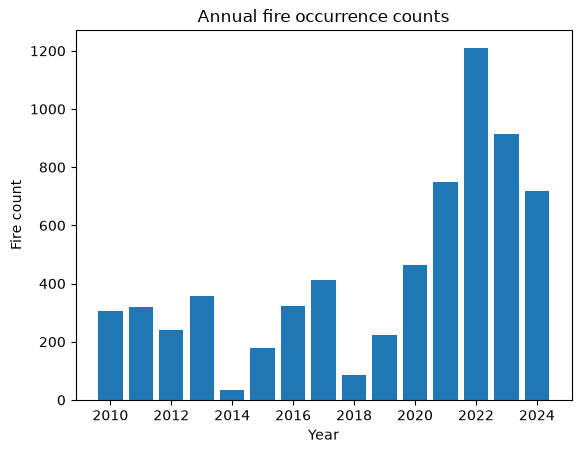

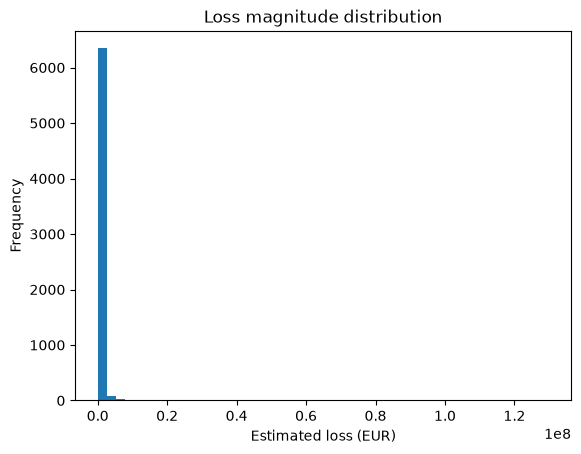

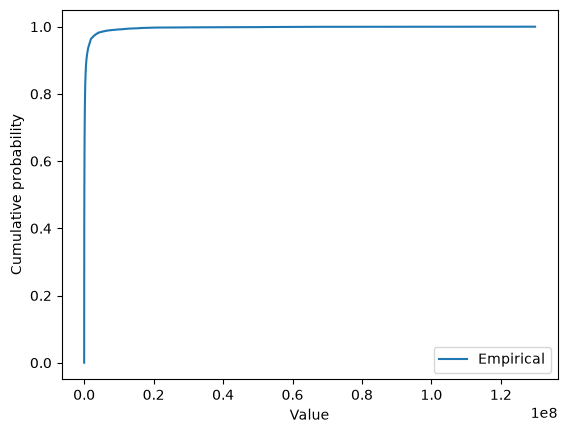

In [10]:
plot_annual_fire_counts(processed_df)
plt.show()

plot_loss_histogram(processed_df)
plt.show()

plot_empirical_cdf(processed_df["Estimated_Loss_EUR"].values)
plt.show()

## Cross-validation against independent aggregate sources

Compares the real large-fire dataset against live OWID/GWIS annual
aggregates (all fire sizes), as an independent sanity check rather than a
reconciliation - the two sources measure different things (see "Data gaps
and assumptions").

In [11]:
owid_counts = fetch_annual_fire_counts()
owid_counts = owid_counts[owid_counts["year"] <= MAX_YEAR]
gwis_area = fetch_annual_burnt_area()
gwis_area = gwis_area[gwis_area["year"] <= MAX_YEAR]

real_annual = processed_df.groupby(processed_df["Date"].dt.year).agg(
    real_large_fire_count=("Burned_Area_ha", "size"),
    real_large_fire_area_ha=("Burned_Area_ha", "sum"),
)
real_annual.index.name = "year"

comparison = real_annual.join(owid_counts.set_index("year")).join(gwis_area.set_index("year"))
comparison["large_fire_vs_gwis_ratio_pct"] = (
    comparison["real_large_fire_area_ha"] / comparison["burnt_area_ha"] * 100
)
print(comparison)
print()

total_ratio = comparison["real_large_fire_area_ha"].sum() / comparison["burnt_area_ha"].sum() * 100
print(f"Total-to-total ratio across all years (properly weighted): {total_ratio:.1f}%")
print("A simple mean of the per-year ratios above would overstate the disagreement, since it")
print("weights small-magnitude years (e.g. 2021, 197%) the same as large ones (e.g. 2017, 108%).")
print("The total-to-total figure is a modest ~6% overshoot, within the normal disagreement range")
print("between independent satellite burnt-area products.")
print()

rolling = comparison[["real_large_fire_area_ha", "burnt_area_ha"]].rolling(3).sum().dropna()
rolling["ratio_3yr_pct"] = rolling["real_large_fire_area_ha"] / rolling["burnt_area_ha"] * 100
print("3-year rolling ratio (smooths out single-year noise):")
print(rolling["ratio_3yr_pct"])
print()
print("This does show a real temporal pattern: ~92-108% through 2012-2019, rising to")
print("~114-134% for 2020-2024. The cause of that recent-years divergence is not fully")
print("explained here - flagged as an open question rather than resolved, see Data gaps.")

      real_large_fire_count  real_large_fire_area_ha  fire_count  \
year                                                               
2010                    307                   127932         NaN   
2011                    319                    64849         NaN   
2012                    239                   101342       815.0   
2013                    359                   154203      1143.0   
2014                     35                    11574       175.0   
2015                    177                    47465       600.0   
2016                    322                   166096       975.0   
2017                    414                   563682      1365.0   
2018                     86                    37356       209.0   
2019                    222                    34665       359.0   
2020                    465                    65786       323.0   
2021                    748                    31576       284.0   
2022                   1210                   11

## Domain validation: order-of-magnitude sanity check

Per the PRD's Domain Validation criterion, checked here early rather than
waiting for Phase 4: does the modeled annual loss land in the right ballpark
for well-documented years? Now on real per-fire data, this is a genuine
test of the calibration constant, not just the synthesis method.

In [12]:
annual_modeled_loss = processed_df.groupby(processed_df["Date"].dt.year)["Estimated_Loss_EUR"].sum()
print(annual_modeled_loss.map(lambda x: f"EUR {x:,.0f}"))

print("\nReference points from published reporting:")
print("2017 total losses (June + October fires): ~EUR 1.5bn (October 2017 Iberian wildfires)")
print("Typical non-catastrophic year: ~EUR 60-140m/year (OECD/press reporting)")
print("2022 Serra da Estrela fire alone (EMSR618): ~25,000 ha, largest fire in 50 years")
print("2024 Central Madeira fire (EMSR748): >5,000 ha burnt vegetation")
print("2024 mainland fire, Centro region (Reriz e Gafanhao, Sep 2024): 35,523 ha in this")
print("  dataset - plausibly the fire behind EMSR760, though not confirmed against the")
print("  activation record")

Date
2010      EUR 246,023,077
2011      EUR 124,709,615
2012      EUR 194,888,462
2013      EUR 296,544,231
2014       EUR 22,257,692
2015       EUR 91,278,846
2016      EUR 319,415,385
2017    EUR 1,084,003,846
2018       EUR 71,838,462
2019       EUR 66,663,462
2020      EUR 126,511,538
2021       EUR 60,723,077
2022      EUR 215,371,154
2023       EUR 82,726,923
2024      EUR 283,823,077
Name: Estimated_Loss_EUR, dtype: str

Reference points from published reporting:
2017 total losses (June + October fires): ~EUR 1.5bn (October 2017 Iberian wildfires)
Typical non-catastrophic year: ~EUR 60-140m/year (OECD/press reporting)
2022 Serra da Estrela fire alone (EMSR618): ~25,000 ha, largest fire in 50 years
2024 Central Madeira fire (EMSR748): >5,000 ha burnt vegetation
2024 mainland fire, Centro region (Reriz e Gafanhao, Sep 2024): 35,523 ha in this
  dataset - plausibly the fire behind EMSR760, though not confirmed against the
  activation record


## Data gaps and assumptions

**Frequency and severity data (real, per-fire):**
- Source: EFFIS's Rapid Damage Assessment (MODIS-based) fire database,
  obtained via EFFIS's official Data Request Form as a one-time manual
  submission for Portugal, 2010-01-01 to 2024-12-31. This is a static
  file committed to `data/raw/`, not a live API - no reproducibility
  drift risk for this component.
- **Scope caveat (from EFFIS's own documentation)**: this product maps
  fires of roughly 30 ha or larger, representing an estimated 75-80% of
  total burnt area despite being a minority of total fire count. **A
  "fire event" in this model therefore specifically means a mapped
  ~30ha+ fire, not every ignition in Portugal.** This is a deliberate,
  documented scope choice: for a catastrophe loss model focused on tail
  risk (VaR, Expected Shortfall), immaterial small fires don't drive the
  numbers that matter, and this keeps frequency and severity internally
  consistent (both drawn from the same real dataset).
- 40 of 6,608 raw records had `area_ha <= 0` and were dropped as
  non-physical mapping artifacts (EFFIS's own notes mention small/
  unmapped islands within a burn scar as a known source of this).
- 69 further records were exact duplicates (same parish, area, and
  timestamp logged under a different `id`), all tiny fires (1-12 ha)
  concentrated in 2021-2024. Confirmed as a real export artifact and
  deduplicated in `load_effis_fire_database`; total impact was ~104 ha
  out of 1.71M ha, immaterial to the model but worth fixing since it was
  a genuine defect rather than a methodology difference.
- **A real discrepancy found during cross-validation, not hidden**: this
  dataset's annual large-fire counts are sometimes *higher* than OWID's
  all-fire (VIIRS-based) counts for the same year (see the
  cross-validation table above, e.g. 2022). This looks backwards at
  first glance but reflects a real methodology difference: EFFIS's MODIS
  Rapid Damage Assessment maps burnt-area *polygons* (250m resolution,
  refined by visual interpretation), while OWID/GWIS's fire *count*
  series is built from VIIRS thermal-anomaly point detections clustered
  into events - a different sensor, a different unit of counting, and a
  different minimum-size behavior. The two series are not expected to
  reconcile, and this dataset is treated as authoritative for this model
  since it directly measures what's being modeled (mapped events with a
  real attached area).
- **A second discrepancy, now mostly explained**: an earlier pass reported
  summed real large-fire area exceeding GWIS's total in every year by a
  "mean ratio" of 116.6%, which looked alarming. That statistic was
  itself misleading (an unweighted mean of ratios over-weights small years
  like 2021). The properly weighted total-to-total ratio across all 15
  years is ~106%, a modest overshoot within the normal disagreement range
  between independent satellite burnt-area products. A real, smaller
  puzzle remains: a 3-year rolling view shows ~92-108% agreement through
  2012-2019, rising to ~114-134% for 2020-2024. That recent-years
  divergence is not fully explained (checked and ruled out: it is not
  caused by the duplicate records above, which are too small in area to
  matter) - left as an open question rather than force-resolved. See the
  "Cross-validation" section above for the full working.
- `Location` is the real NUTS2-level region (EFFIS's `admlvl2` field).
  Finer `admlvl3`/`admlvl5` fields exist in the raw file but are
  intentionally unused, matching the PRD's explicit exclusion of
  sub-regional/spatial granularity from scope.

**Loss calibration (EUR/ha):**
- No source publishes verified EUR loss per individual fire. A single
  documented calibration constant (long-run 1975-2021 ICNF-derived
  average, ~EUR 1,923/ha) is applied uniformly to every real fire's
  burnt area.
- **Known limitation**: real losses are not strictly linear in burnt
  area - a catastrophic wildland-urban-interface fire (e.g. 2017, at an
  implied ~EUR 2,865/ha) carries far higher losses per hectare than a
  remote forest fire, because fatalities and structure loss dominate,
  not hectares burned. Flagged as a named limitation for the Phase 4/5
  write-up, not hidden in the numbers.

**Superseded approach**: an earlier version of this notebook synthesized
individual fire records to match real annual aggregates, since the real
per-fire database hadn't arrived yet. That synthesis step has been fully
replaced now that real data is available - see `docs/worklog.md` for that
history.